# 05 XGBoost — Optimized Single Model

## Perbaikan dari versi sebelumnya

| Masalah | Versi Lama | Versi Baru |
|---------|-----------|------------|
| Feature selection | RF importance (cross-model bias) | Tidak digunakan — XGBoost pakai L1/L2 regularization sendiri |
| SMOTE leakage | SMOTE sebelum CV / di semua data | `sample_weight` XGBoost-native (lebih principled) |
| Enrolled boost | Weight 1.0 (sama semua) | `enrolled_boost` dioptimasi Optuna |
| Hyperparameter | Fixed, generik | Optuna 80 trials + XGBoost-specific params |
| Early stopping | Tidak ada | Dipakai pada final model |
| Threshold tuning | OOF (sudah benar) | OOF + grid lebih halus |
| Feature selection leakage | Dievaluasi di test set | Tidak ada feature selection manual |

**Mengapa `sample_weight` bukan SMOTE untuk XGBoost?**  
XGBoost menggunakan `sample_weight` langsung dalam komputasi gradient — minority class samples berkontribusi lebih besar ke loss. SMOTE menciptakan data sintetis yang bisa corrupt structure asli data. Untuk gradient boosting, sample weighting lebih principled.

---
## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict
)
from sklearn.preprocessing import TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.base import clone

RANDOM_STATE = 42
TEST_SIZE    = 0.20
class_names  = ['Graduate', 'Enrolled', 'Dropout']

print(f"XGBoost version : {xgb.__version__}")
print("Setup done.")

XGBoost version : 3.2.0
Setup done.


---
## 1. Load Data & Feature Engineering

In [2]:
df = pd.read_csv('../data/data.csv', delimiter=';')
df.columns = df.columns.str.strip().str.replace('\t', '')

target_map = {'Graduate': 0, 'Enrolled': 1, 'Dropout': 2}
df['target'] = df['Target'].map(target_map)

# ── Aliases ──────────────────────────────────────────────────────────────────
S1e = df['Curricular units 1st sem (enrolled)']
S1a = df['Curricular units 1st sem (approved)']
S1g = df['Curricular units 1st sem (grade)']
S1v = df['Curricular units 1st sem (evaluations)']
S1c = df['Curricular units 1st sem (credited)']
S1w = df['Curricular units 1st sem (without evaluations)']
S2e = df['Curricular units 2nd sem (enrolled)']
S2a = df['Curricular units 2nd sem (approved)']
S2g = df['Curricular units 2nd sem (grade)']
S2v = df['Curricular units 2nd sem (evaluations)']
S2c = df['Curricular units 2nd sem (credited)']
S2w = df['Curricular units 2nd sem (without evaluations)']

def safe_div(num, den):
    return np.where(den > 0, num / den, 0.0)

# Academic ratios
df['success_rate_1st']      = safe_div(S1a, S1e)
df['success_rate_2nd']      = safe_div(S2a, S2e)
df['success_rate_total']    = safe_div(S1a + S2a, S1e + S2e)
df['eval_rate_1st']         = safe_div(S1v, S1e)
df['eval_rate_2nd']         = safe_div(S2v, S2e)
df['without_eval_rate_1st'] = safe_div(S1w, S1e)
df['without_eval_rate_2nd'] = safe_div(S2w, S2e)
df['credit_util_1st']       = safe_div(S1c, S1e)
df['credit_util_2nd']       = safe_div(S2c, S2e)

# Trends
df['grade_improvement']     = S2g - S1g
df['approval_improvement']  = S2a - S1a
df['eval_improvement']      = S2v - S1v
df['success_rate_change']   = df['success_rate_2nd'] - df['success_rate_1st']
df['enrollment_decline']    = (S2e < S1e).astype(int)

# Failure signals
df['fail_count_1st']        = (S1e - S1a).clip(lower=0)
df['fail_count_2nd']        = (S2e - S2a).clip(lower=0)
df['total_fails']           = df['fail_count_1st'] + df['fail_count_2nd']
df['fail_rate_1st']         = safe_div(df['fail_count_1st'], S1e)
df['fail_rate_2nd']         = safe_div(df['fail_count_2nd'], S2e)
df['is_failing_1st']        = ((S1g > 0) & (S1g < 10)).astype(int)
df['is_failing_2nd']        = ((S2g > 0) & (S2g < 10)).astype(int)
df['low_approval_1st']      = (df['success_rate_1st'] < 0.5).astype(int)
df['low_approval_2nd']      = (df['success_rate_2nd'] < 0.5).astype(int)
df['zero_eval_1st']         = (S1v == 0).astype(int)
df['zero_eval_2nd']         = (S2v == 0).astype(int)
df['zero_eval_both']        = (df['zero_eval_1st'] & df['zero_eval_2nd']).astype(int)
df['has_without_eval_1st']  = (S1w > 0).astype(int)
df['has_without_eval_2nd']  = (S2w > 0).astype(int)
df['dropping_trend']        = ((df['grade_improvement'] < -1) & (df['approval_improvement'] < 0)).astype(int)

# Academic health composites
df['acad_health_1st']       = (df['success_rate_1st'] * 0.4 + safe_div(S1g, 20) * 0.4 + (1 - df['without_eval_rate_1st']) * 0.2)
df['acad_health_2nd']       = (df['success_rate_2nd'] * 0.4 + safe_div(S2g, 20) * 0.4 + (1 - df['without_eval_rate_2nd']) * 0.2)
df['acad_trajectory']       = df['acad_health_2nd'] - df['acad_health_1st']
df['grade_avg']             = (S1g + S2g) / 2
df['total_approved']        = S1a + S2a
df['total_enrolled']        = S1e + S2e
df['admission_norm']        = df['Admission grade'] / 10
df['prevqual_norm']         = df['Previous qualification (grade)'] / 10
df['grade_vs_admission']    = df['grade_avg'] - df['admission_norm']

# Financial
df['financial_risk']        = ((df['Tuition fees up to date'] == 0).astype(int) * 2 +
                                df['Debtor'] + (df['Scholarship holder'] == 0).astype(int))
df['tuition_no_scholar']    = ((df['Tuition fees up to date'] == 0) & (df['Scholarship holder'] == 0)).astype(int)
df['debtor_no_scholar']     = ((df['Debtor'] == 1) & (df['Scholarship holder'] == 0)).astype(int)

# Demographic
df['is_older']              = (df['Age at enrollment'] >= 25).astype(int)
df['is_very_old']           = (df['Age at enrollment'] >= 35).astype(int)

# Macro
df['economic_stress']       = df['Unemployment rate'] * df['Inflation rate']
df['gdp_per_unemp']         = safe_div(df['GDP'], df['Unemployment rate'])

# Interactions
df['fail_x_financial']      = df['total_fails']      * df['financial_risk']
df['age_x_financial']       = df['Age at enrollment'] * df['financial_risk']
df['success_x_tuition']     = df['success_rate_total'] * df['Tuition fees up to date']
df['health2_x_financial']   = df['acad_health_2nd']  * (4 - df['financial_risk'])

print(f"Shape after feature engineering: {df.shape}")
print("\nClass distribution:")
for k, v in target_map.items():
    n = (df['target'] == v).sum()
    print(f"  {v} → {k}: {n} ({n/len(df)*100:.1f}%)")

Shape after feature engineering: (4424, 87)

Class distribution:
  0 → Graduate: 2209 (49.9%)
  1 → Enrolled: 794 (17.9%)
  2 → Dropout: 1421 (32.1%)


---
## 2. Feature Groups & Train-Test Split

In [3]:
nominal_cols = [
    'Marital status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

numeric_cols = [
    'Application order', 'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

binary_cols = [
    'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International', 'Daytime/evening attendance'
]

engineered_cols = [
    'success_rate_1st', 'success_rate_2nd', 'success_rate_total',
    'eval_rate_1st', 'eval_rate_2nd', 'without_eval_rate_1st', 'without_eval_rate_2nd',
    'credit_util_1st', 'credit_util_2nd', 'grade_improvement', 'approval_improvement',
    'eval_improvement', 'success_rate_change', 'enrollment_decline',
    'fail_count_1st', 'fail_count_2nd', 'total_fails', 'fail_rate_1st', 'fail_rate_2nd',
    'is_failing_1st', 'is_failing_2nd', 'low_approval_1st', 'low_approval_2nd',
    'zero_eval_1st', 'zero_eval_2nd', 'zero_eval_both',
    'has_without_eval_1st', 'has_without_eval_2nd', 'dropping_trend',
    'acad_health_1st', 'acad_health_2nd', 'acad_trajectory',
    'grade_avg', 'total_approved', 'total_enrolled',
    'admission_norm', 'prevqual_norm', 'grade_vs_admission',
    'financial_risk', 'tuition_no_scholar', 'debtor_no_scholar',
    'is_older', 'is_very_old', 'economic_stress', 'gdp_per_unemp',
    'fail_x_financial', 'age_x_financial', 'success_x_tuition', 'health2_x_financial'
]

all_cols = nominal_cols + numeric_cols + binary_cols + engineered_cols

X = df[all_cols].copy()
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Total features: {X.shape[1]}")
print(f"  Nominal (TargetEncode): {len(nominal_cols)}")
print(f"  Numeric              : {len(numeric_cols)}")
print(f"  Binary               : {len(binary_cols)}")
print(f"  Engineered           : {len(engineered_cols)}")
print(f"\nTrain: {X_train_raw.shape} | Test: {X_test_raw.shape}")

Total features: 85
  Nominal (TargetEncode): 9
  Numeric              : 19
  Binary               : 8
  Engineered           : 49

Train: (3539, 85) | Test: (885, 85)


---
## 3. Target Encoding for Nominal Features

sklearn TargetEncoder (≥1.3) menggunakan internal cross-fitting saat `fit_transform()` — sehingga tidak terjadi target leakage meskipun fit dan transform pada data yang sama.

In [4]:
te = TargetEncoder(target_type='multiclass', smooth='auto', random_state=RANDOM_STATE)

# fit_transform pada train: internal cross-fitting prevents leakage
X_train_nom = te.fit_transform(X_train_raw[nominal_cols], y_train)
X_test_nom  = te.transform(X_test_raw[nominal_cols])

passthrough = numeric_cols + binary_cols + engineered_cols

X_train = np.hstack([
    X_train_raw[passthrough].values.astype(float),
    X_train_nom
])
X_test = np.hstack([
    X_test_raw[passthrough].values.astype(float),
    X_test_nom
])

# Feature names after TargetEncoder (multiclass = 3 cols per nominal feature)
te_names = [f'{col}_class{c}' for col in nominal_cols for c in range(3)]
all_feat_names = passthrough + te_names

print(f"X_train encoded: {X_train.shape}")
print(f"X_test  encoded: {X_test.shape}")
print(f"Total feature columns: {len(all_feat_names)}")

X_train encoded: (3539, 103)
X_test  encoded: (885, 103)
Total feature columns: 103


---
## 4. Class Imbalance — Sample Weights

**Mengapa sample_weight bukan SMOTE?**
- XGBoost mengintegrasikan weight langsung ke dalam gradient computation
- SMOTE menciptakan titik data sintetis yang bisa memperkenalkan noise
- Dengan boosting, sample_weight lebih mathematically principled

Kita juga menambahkan `enrolled_boost` sebagai parameter Optuna — karena Enrolled adalah kelas yang paling susah (kecil + overlap dengan Graduate dan Dropout).

In [5]:
def compute_weights(y, enrolled_boost=1.0):
    """
    Compute sample weights:
      - Base: balanced class weights (n_samples / (n_classes × n_class_i))
      - Enrolled: additionally multiplied by enrolled_boost
    """
    sw = compute_sample_weight('balanced', y)
    sw[y == 1] *= enrolled_boost  # class 1 = Enrolled
    return sw

# Preview baseline weights
sw_base = compute_weights(y_train, enrolled_boost=1.0)
for i, name in enumerate(class_names):
    mask = (y_train == i)
    print(f"  {name}: n={mask.sum()}, weight_mean={sw_base[mask].mean():.4f}")

  Graduate: n=1767, weight_mean=0.6676
  Enrolled: n=635, weight_mean=1.8577
  Dropout: n=1137, weight_mean=1.0375


---
## 5. Optuna Hyperparameter Tuning

**Mengapa Optuna untuk XGBoost?**  
Berbeda dengan RF, XGBoost punya interaction yang kuat antar parameter (learning_rate ↔ n_estimators, depth ↔ min_child_weight). Optuna (TPE) lebih efisien dari RandomizedSearchCV dalam menangkap interaksi ini.

**Search space:**
- Architecture: `max_depth`, `n_estimators`, `learning_rate`
- Row/column sampling: `subsample`, `colsample_bytree`, `colsample_bylevel`
- Regularization (penting untuk XGBoost!): `reg_alpha` (L1), `reg_lambda` (L2), `gamma`, `min_child_weight`
- Imbalance: `enrolled_boost` (multiplier untuk class Enrolled)
- Tree method: `grow_policy` (depthwise vs lossguide)

In [6]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 5.0),
        'max_delta_step'   : trial.suggest_int('max_delta_step', 0, 5),  # helps imbalanced multiclass
        'grow_policy'      : trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
    }
    enrolled_boost = trial.suggest_float('enrolled_boost', 1.0, 4.0)

    oof_preds = np.zeros(len(X_train), dtype=int)
    for tr_idx, val_idx in cv_inner.split(X_train, y_train):
        sw = compute_weights(y_train[tr_idx], enrolled_boost)
        model = xgb.XGBClassifier(
            **params,
            objective='multi:softprob',
            num_class=3,
            tree_method='hist',
            eval_metric='mlogloss',
            use_label_encoder=False,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )
        model.fit(
            X_train[tr_idx], y_train[tr_idx],
            sample_weight=sw,
            verbose=False
        )
        oof_preds[val_idx] = model.predict(X_train[val_idx])

    return f1_score(y_train, oof_preds, average='macro')


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.NopPruner()
)
print("Starting Optuna (80 trials, 5-fold OOF per trial)...")
study.optimize(xgb_objective, n_trials=80, show_progress_bar=True)

best = study.best_params
enrolled_boost_best = best.pop('enrolled_boost')

print(f"\nBest OOF F1 macro  : {study.best_value:.4f}")
print(f"Best enrolled_boost: {enrolled_boost_best:.3f}")
print("Best XGBoost params:")
for k, v in best.items():
    print(f"  {k}: {v}")

Starting Optuna (80 trials, 5-fold OOF per trial)...


Best trial: 44. Best value: 0.730786: 100%|██████████| 80/80 [21:03<00:00, 15.79s/it]


Best OOF F1 macro  : 0.7308
Best enrolled_boost: 1.753
Best XGBoost params:
  n_estimators: 500
  max_depth: 8
  learning_rate: 0.09934177365368022
  subsample: 0.8397743541230832
  colsample_bytree: 0.8565061305861145
  colsample_bylevel: 0.5421073308660187
  min_child_weight: 6
  gamma: 0.5351998253294399
  reg_alpha: 0.3609487150036084
  reg_lambda: 2.802165253963567
  max_delta_step: 0
  grow_policy: lossguide


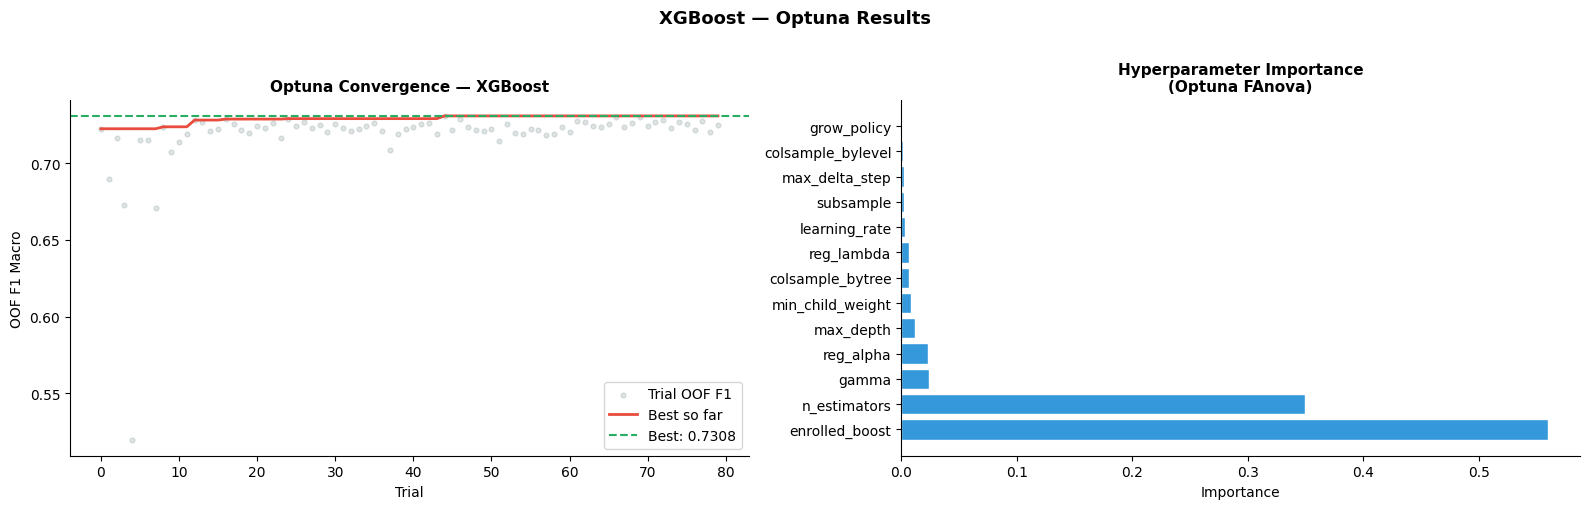

In [7]:
# ── Optuna convergence plot ───────────────────────────────────────────────────
vals        = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(range(len(vals)), vals, alpha=0.3, s=12, color='#95a5a6', label='Trial OOF F1')
axes[0].plot(best_so_far, color='#e74c3c', linewidth=2, label='Best so far')
axes[0].axhline(study.best_value, linestyle='--', color='#27ae60', linewidth=1.5,
                label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('OOF F1 Macro')
axes[0].set_title('Optuna Convergence — XGBoost', fontsize=11, fontweight='bold')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

# Parameter importance plot using Optuna
try:
    param_imp = optuna.importance.get_param_importances(study)
    params_sorted = list(param_imp.keys())
    imp_vals     = [param_imp[k] for k in params_sorted]
    axes[1].barh(params_sorted, imp_vals, color='#3498db', edgecolor='white')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance\n(Optuna FAnova)', fontsize=11, fontweight='bold')
    axes[1].spines[['top', 'right']].set_visible(False)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Parameter importance\nunavailable: {e}',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('XGBoost — Optuna Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Final Model Training with Early Stopping

**Strategy:**  
1. Hold out 15% dari X_train sebagai early stopping validation set  
2. Train dengan best Optuna params + `n_estimators=1000`, early stopping akan berhenti di round optimal  
3. Catat `best_iteration`  
4. Retrain pada FULL X_train dengan `n_estimators = best_iteration` (no data wasted)

In [9]:
# ============================================================================
# EARLY STOPPING XGBOOST (PERBAIKAN)
# ============================================================================

# ── Step 0: Hapus n_estimators dari best params (karena akan di-set manual) ──
best_no_estimators = {k: v for k, v in best.items() if k != 'n_estimators'}

print("Best params without n_estimators:")
for k, v in best_no_estimators.items():
    print(f"  {k}: {v}")

# ── Step 1: Early stopping on 85/15 split ────────────────────────────────────
X_tr_es, X_val_es, y_tr_es, y_val_es = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
)
sw_es = compute_weights(y_tr_es, enrolled_boost_best)

model_es = xgb.XGBClassifier(
    **best_no_estimators,          # ← tanpa n_estimators
    n_estimators=1000,             # ← set besar untuk early stopping
    early_stopping_rounds=40,
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

model_es.fit(
    X_tr_es, y_tr_es,
    sample_weight=sw_es,
    eval_set=[(X_val_es, y_val_es)],
    verbose=False
)

best_n_estimators = model_es.best_iteration + 1
print(f"\n✅ Early stopping → best iteration: {best_n_estimators}")

# ── Step 2: Retrain on FULL X_train with optimal n_estimators ─────────────────
sw_full = compute_weights(y_train, enrolled_boost_best)

final_model = xgb.XGBClassifier(
    **best_no_estimators,          # ← tanpa n_estimators
    n_estimators=best_n_estimators, # ← hasil dari early stopping
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

final_model.fit(
    X_train, y_train,
    sample_weight=sw_full,
    verbose=False
)

print(f"✅ Final model trained: {best_n_estimators} trees on {X_train.shape[0]} samples")

Best params without n_estimators:
  max_depth: 8
  learning_rate: 0.09934177365368022
  subsample: 0.8397743541230832
  colsample_bytree: 0.8565061305861145
  colsample_bylevel: 0.5421073308660187
  min_child_weight: 6
  gamma: 0.5351998253294399
  reg_alpha: 0.3609487150036084
  reg_lambda: 2.802165253963567
  max_delta_step: 0
  grow_policy: lossguide

✅ Early stopping → best iteration: 89
✅ Final model trained: 89 trees on 3539 samples


---
## 7. OOF Threshold Tuning

Threshold optimal dicari dari OOF predictions — bukan test set.

In [11]:
# ============================================================================
# OOF PROBABILITIES FOR THRESHOLD TUNING (PERBAIKAN)
# ============================================================================

print("Computing OOF probabilities untuk threshold tuning...")

# ── Step 0: Hapus n_estimators dari best params ──────────────────────────────
best_no_estimators = {k: v for k, v in best.items() if k != 'n_estimators'}

# ── Step 1: OOF dengan cross-validation ───────────────────────────────────────
oof_probs = np.zeros((len(X_train), 3))

for tr_idx, val_idx in cv_inner.split(X_train, y_train):
    sw_fold = compute_weights(y_train[tr_idx], enrolled_boost_best)
    
    # Gunakan best_no_estimators + n_estimators terpisah
    m = xgb.XGBClassifier(
        **best_no_estimators,           # ← tanpa n_estimators
        n_estimators=best_n_estimators, # ← dari early stopping
        objective='multi:softprob',
        num_class=3,
        tree_method='hist',
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    
    m.fit(X_train[tr_idx], y_train[tr_idx], sample_weight=sw_fold, verbose=False)
    oof_probs[val_idx] = m.predict_proba(X_train[val_idx])

# ── Step 2: Evaluasi default threshold ────────────────────────────────────────
oof_preds_default = oof_probs.argmax(axis=1)
print(f"OOF F1 macro (default threshold): {f1_score(y_train, oof_preds_default, average='macro'):.4f}")

# ── Step 3: Grid search threshold terbaik ─────────────────────────────────────
def apply_thresholds(probs, thresholds):
    return (probs - np.array(thresholds)).argmax(axis=1)

best_f1_oof, best_thresh = 0, [1/3, 1/3, 1/3]
grid = np.arange(0.10, 0.65, 0.03)

print("Searching best thresholds...")
for t0 in grid:
    for t1 in grid:
        for t2 in grid:
            preds = apply_thresholds(oof_probs, [t0, t1, t2])
            f1 = f1_score(y_train, preds, average='macro')
            if f1 > best_f1_oof:
                best_f1_oof, best_thresh = f1, [t0, t1, t2]

print(f"\n✅ Best thresholds [Graduate, Enrolled, Dropout]: {[round(t,2) for t in best_thresh]}")
print(f"✅ OOF F1 macro with tuned thresholds           : {best_f1_oof:.4f}")

Computing OOF probabilities untuk threshold tuning...
OOF F1 macro (default threshold): 0.7214
Searching best thresholds...

✅ Best thresholds [Graduate, Enrolled, Dropout]: [np.float64(0.1), np.float64(0.31), np.float64(0.25)]
✅ OOF F1 macro with tuned thresholds           : 0.7298


---
## 8. Evaluation on Test Set

In [12]:
y_prob_test    = final_model.predict_proba(X_test)
y_pred_default = final_model.predict(X_test)
y_pred_tuned   = apply_thresholds(y_prob_test, best_thresh)

print("=" * 70)
print("XGBOOST OPTIMIZED — TEST SET RESULTS")
print("=" * 70)

print("\n--- Default threshold ---")
print(classification_report(y_test, y_pred_default, target_names=class_names, digits=4))

print("\n--- OOF-tuned threshold (no leakage) ---")
print(classification_report(y_test, y_pred_tuned, target_names=class_names, digits=4))

try:
    print(f"ROC AUC (OvR): {roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='macro'):.4f}")
    print(f"ROC AUC (OvO): {roc_auc_score(y_test, y_prob_test, multi_class='ovo', average='macro'):.4f}")
except Exception as e:
    print(f"AUC: {e}")

y_pred_final = y_pred_tuned
f1s_final    = f1_score(y_test, y_pred_final, average=None)

XGBOOST OPTIMIZED — TEST SET RESULTS

--- Default threshold ---
              precision    recall  f1-score   support

    Graduate     0.8406    0.8235    0.8320       442
    Enrolled     0.5096    0.6667    0.5777       159
     Dropout     0.8811    0.7570    0.8144       284

    accuracy                         0.7740       885
   macro avg     0.7438    0.7491    0.7414       885
weighted avg     0.7942    0.7740    0.7807       885


--- OOF-tuned threshold (no leakage) ---
              precision    recall  f1-score   support

    Graduate     0.8259    0.8801    0.8521       442
    Enrolled     0.5549    0.6038    0.5783       159
     Dropout     0.8921    0.7570    0.8190       284

    accuracy                         0.7910       885
   macro avg     0.7576    0.7470    0.7498       885
weighted avg     0.7985    0.7910    0.7923       885

ROC AUC (OvR): 0.9000
ROC AUC (OvO): 0.8912


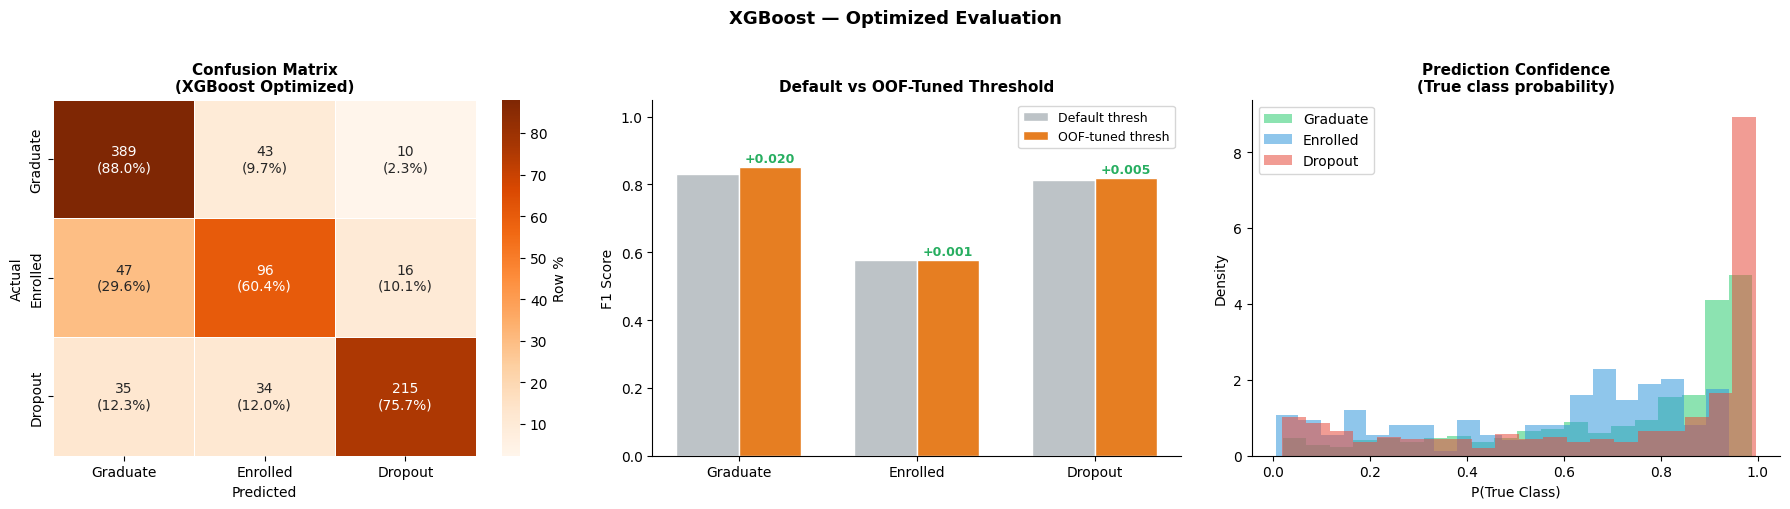

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm     = confusion_matrix(y_test, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                    for rc, rp in zip(cm, cm_pct)])
sns.heatmap(cm_pct, ax=axes[0], annot=annot, fmt='', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Row %'})
axes[0].set_title('Confusion Matrix\n(XGBoost Optimized)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Default vs tuned F1
f1_default = f1_score(y_test, y_pred_default, average=None)
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, f1_default, w, label='Default thresh', color='#bdc3c7', edgecolor='white')
axes[1].bar(x + w/2, f1s_final,  w, label='OOF-tuned thresh', color='#e67e22', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('F1 Score')
axes[1].set_title('Default vs OOF-Tuned Threshold', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top', 'right']].set_visible(False)
for i, (d, t) in enumerate(zip(f1_default, f1s_final)):
    delta = t - d
    col   = '#27ae60' if delta >= 0 else '#e74c3c'
    axes[1].text(i + w/2, t + 0.015, f'{delta:+.3f}',
                 ha='center', fontsize=9, color=col, fontweight='bold')

# Confidence distribution
for i, (cls, col) in enumerate(zip(class_names, ['#2ecc71', '#3498db', '#e74c3c'])):
    axes[2].hist(y_prob_test[y_test == i, i], bins=20, alpha=0.55,
                 density=True, color=col, label=cls)
axes[2].set_xlabel('P(True Class)'); axes[2].set_ylabel('Density')
axes[2].set_title('Prediction Confidence\n(True class probability)', fontsize=11, fontweight='bold')
axes[2].legend(); axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('XGBoost — Optimized Evaluation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance (XGBoost-Native)

XGBoost menyediakan 3 jenis importance:
- **Gain**: rata-rata improvement dalam loss function per split — paling informatif
- **Cover**: rata-rata jumlah samples yang tercakup per split
- **Frequency**: berapa kali fitur dipakai untuk split (bisa bias ke fitur biner)

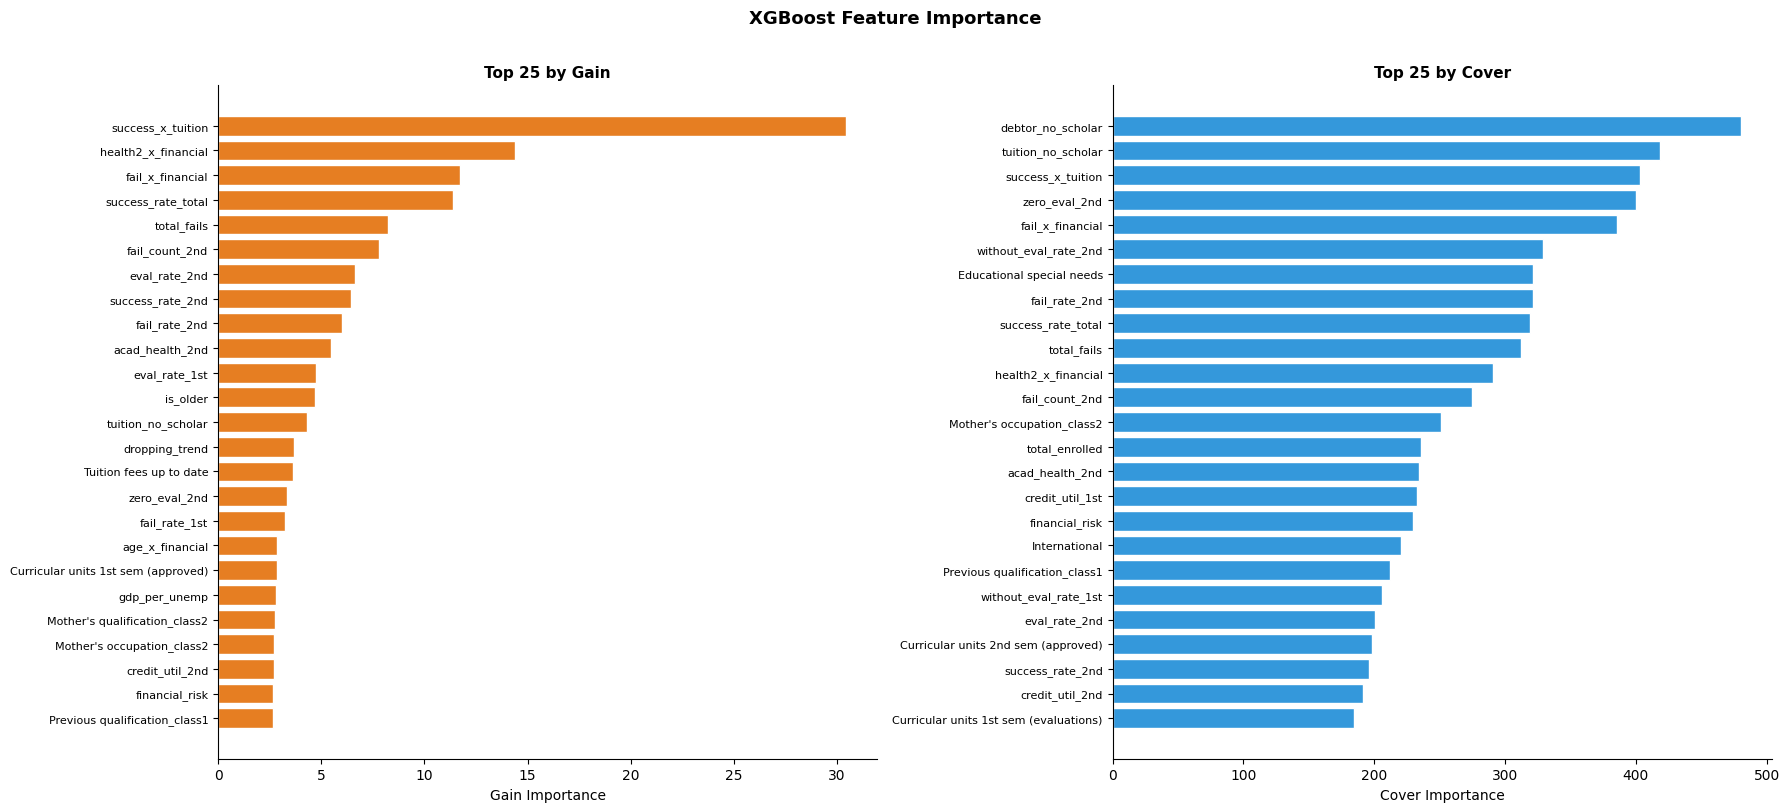

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, imp_type, color in [
    (axes[0], 'gain',      '#e67e22'),
    (axes[1], 'cover',     '#3498db'),
]:
    scores = final_model.get_booster().get_score(importance_type=imp_type)
    # Map f-index back to feature name
    fi_df = pd.DataFrame([
        {
            'Feature': (all_feat_names[int(k[1:])] if k.startswith('f') and k[1:].isdigit() else k),
            'Importance': v
        }
        for k, v in scores.items()
    ]).sort_values('Importance', ascending=False).head(25)

    ax.barh(range(len(fi_df)), fi_df['Importance'][::-1].values,
            color=color, edgecolor='white')
    ax.set_yticks(range(len(fi_df)))
    ax.set_yticklabels(fi_df['Feature'][::-1].values, fontsize=8)
    ax.set_xlabel(f'{imp_type.capitalize()} Importance')
    ax.set_title(f'Top 25 by {imp_type.capitalize()}', fontsize=11, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('XGBoost Feature Importance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Summary & Save

In [15]:
xgb_bundle = {
    'model'            : final_model,
    'target_encoder'   : te,
    'feature_names'    : all_feat_names,
    'best_params'      : best,
    'enrolled_boost'   : enrolled_boost_best,
    'best_n_estimators': best_n_estimators,
    'best_thresh'      : best_thresh,
    'optuna_best_value': study.best_value,
    'oof_f1_macro'     : best_f1_oof,
    'test_accuracy'    : accuracy_score(y_test, y_pred_final),
    'test_f1_macro'    : f1_score(y_test, y_pred_final, average='macro'),
    'test_f1_weighted' : f1_score(y_test, y_pred_final, average='weighted'),
    'f1_per_class'     : dict(zip(class_names, f1s_final)),
    'precision_per_class': dict(zip(class_names, precision_score(y_test, y_pred_final, average=None))),
    'recall_per_class' : dict(zip(class_names, recall_score(y_test, y_pred_final, average=None))),
    'y_pred'           : y_pred_final,
    'y_prob'           : y_prob_test,
    'y_test'           : y_test,
    'class_names'      : class_names,
}
try:
    xgb_bundle['roc_auc_ovr'] = roc_auc_score(y_test, y_prob_test, multi_class='ovr', average='macro')
    xgb_bundle['roc_auc_ovo'] = roc_auc_score(y_test, y_prob_test, multi_class='ovo', average='macro')
except: pass

with open('../data/xgb_bundle.pkl', 'wb') as f:
    pickle.dump(xgb_bundle, f)

print("Saved: ../data/xgb_bundle.pkl")
print()
print("=" * 70)
print("XGBOOST OPTIMIZED — FINAL SUMMARY")
print("=" * 70)
print(f"  Optuna trials          : 80 (5-fold OOF per trial)")
print(f"  Sample weighting       : balanced + enrolled_boost={enrolled_boost_best:.2f}")
print(f"  Feature selection      : NONE (XGBoost regularization handles irrelevant feats)")
print(f"  Early stopping         : {best_n_estimators} trees (from 1000 budget)")
print(f"  Threshold tuning       : OOF (anti-leakage)")
print()
print(f"  Optuna OOF F1 macro    : {xgb_bundle['optuna_best_value']:.4f}")
print(f"  OOF F1 (thresh tuning) : {xgb_bundle['oof_f1_macro']:.4f}")
print(f"  Accuracy               : {xgb_bundle['test_accuracy']:.4f}")
print(f"  F1 macro               : {xgb_bundle['test_f1_macro']:.4f}")
print(f"  F1 weighted            : {xgb_bundle['test_f1_weighted']:.4f}")
try:
    print(f"  ROC AUC OvR            : {xgb_bundle['roc_auc_ovr']:.4f}")
except: pass
print()
print(f"  {'Class':<12} {'F1':>8} {'Precision':>12} {'Recall':>10}")
print(f"  {'-'*46}")
for cls in class_names:
    print(f"  {cls:<12} "
          f"{xgb_bundle['f1_per_class'][cls]:>8.4f} "
          f"{xgb_bundle['precision_per_class'][cls]:>12.4f} "
          f"{xgb_bundle['recall_per_class'][cls]:>10.4f}")

Saved: ../data/xgb_bundle.pkl

XGBOOST OPTIMIZED — FINAL SUMMARY
  Optuna trials          : 80 (5-fold OOF per trial)
  Sample weighting       : balanced + enrolled_boost=1.75
  Feature selection      : NONE (XGBoost regularization handles irrelevant feats)
  Early stopping         : 89 trees (from 1000 budget)
  Threshold tuning       : OOF (anti-leakage)

  Optuna OOF F1 macro    : 0.7308
  OOF F1 (thresh tuning) : 0.7298
  Accuracy               : 0.7910
  F1 macro               : 0.7498
  F1 weighted            : 0.7923
  ROC AUC OvR            : 0.9000

  Class              F1    Precision     Recall
  ----------------------------------------------
  Graduate       0.8521       0.8259     0.8801
  Enrolled       0.5783       0.5549     0.6038
  Dropout        0.8190       0.8921     0.7570
